In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy as sp
import qutip as qt
import xarray as xr
import pandas as pd
import os
import sys
char = r'C:\Users\z5459883\OneDrive - UNSW\Documents\GitHub\Charizard'
if char not in sys.path:
    sys.path.append(char)



# Functions

In [21]:
def wigner_plot_polar(rho, dpi=300, true_zero=False, fig=None, ax=None, cmap='coolwarm'):
    rho = qt.Qobj(rho)
    nTheta, nPhi = (101, 201)
    theta = np.linspace(0, np.pi, num=nTheta, endpoint=True)
    phi = np.linspace(-np.pi, np.pi, num=nPhi, endpoint=True)
    husimi0, theta_mesh, phi_mesh = qt.spin_wigner(rho, theta, phi)

    r = 1
    x = r*np.cos(phi_mesh)*np.cos(theta_mesh-np.pi/2)
    y = r*np.sin(phi_mesh)*np.cos(theta_mesh-np.pi/2)
    z = r*np.sin(theta_mesh-np.pi/2)

    if fig is None:
        fig = plt.figure()
    if ax is None:
        ax = fig.add_subplot(1, 1, 1, projection='hammer')
    if true_zero:
        ax.pcolormesh(phi_mesh, theta_mesh - np.pi/2, husimi0, cmap=cmap, vmin=-husimi0.max(), vmax=husimi0.max())
    else:
        ax.pcolormesh(phi_mesh, theta_mesh - np.pi / 2, husimi0, cmap=cmap)
    ax.set_xticklabels([])
    ax.grid(False)
    return fig, ax


class CatQubit():
    def __init__(self, spin=7/2, axis='Ix'):
        assert spin*2 == int(spin*2), "Spin must be half-integer (e.g., 1/2, 3/2, 5/2, etc.)"
        self.spin = spin
        self.dim = int(2 * spin + 1)
        self.axis = axis
        self.spin_op = {
            'Ix': qt.jmat(spin, 'x'),
            'Iy': qt.jmat(spin, 'y'),
            'Iz': qt.jmat(spin, 'z'),
            'Ix^2': qt.jmat(spin, 'x')**2,
            'Iy^2': qt.jmat(spin, 'y')**2,
            'Iz^2': qt.jmat(spin, 'z')**2,
            'Ip': qt.jmat(spin, '+'),
            'Im': qt.jmat(spin, '-'),
            'I2AT': qt.jmat(spin, '+')**2 + qt.jmat(spin, '-')**2 ,
            'parity': qt.Qobj(np.eye(self.dim) * np.array([1, -1] * (self.dim//2))),
            'Lx_z': qt.Qobj(np.flip(np.eye(self.dim), 1)),
            'Ly_z': qt.Qobj(np.flip(np.eye(self.dim, dtype=np.complex128) *  np.array([*[-1j]*(self.dim//2), *[1j]*(self.dim//2)]), 1)),
            'Lz_z': qt.Qobj(np.eye(self.dim, dtype=np.complex128) *  np.array([*[1]*(self.dim//2), *[-1]*(self.dim//2)])),
            'target_dm': qt.ket2dm(qt.basis(self.dim, 0)),  # Default target state is |0><0|
        }
        self.Hamiltonian_params = {
            # H = fz * Iz + fq * Iz^2 + fq2nd * Iz^3 + B1amp * Ix * NMRdrive + NER1amp * (Ix*Iz + Iz*Ix)/2 + NER2amp * (Ip^2 + Im^2)/2
            'fz': 7.7e6,
            'fq': 25e3,
            'fq2nd': 0,
            'B1amp': 1.0,
            'NER1amp': 1.0,
            'NER2amp': 1.0,
        }
        self.drive_signal = None  # Placeholder for the drive signal
        self.dt = 1e-6  # Default time step for the simulation
        self.t0  = 0.0  # keeps track of current time

        self.state = qt.ket2dm(qt.basis(self.dim, 0))  # Default state is |0><0|
        self.state_list = [] # can store states for later use
        self.state_history_list = []
        self.noise_model = None  # Placeholder for noise model

        self.cmap = plt.get_cmap('coolwarm')  # Default colormap for Wigner plots
        self.black_background = False
        plt.style.use('default')  # Default style for plots
        # plt.style.use('Solarize_Light2')  # Reset to default style for plots
        
    ############# gates and operations #############
    def initialize(self, mz=0):
        self.update_state(qt.ket2dm(qt.basis(self.dim, mz)))
        
    def encode(self, sign=1):
        '''Assumes the state is initialized to |0>. Rotates the state by pi/2 to Ix or Iy axis depending on the specified axis.
        sign: 1 means |0> goes to |0> in Ix basis.'''
        if self.axis == 'Ix':
            orthogonal_op = 'Iy'
        elif self.axis == 'Iy':
            orthogonal_op = 'Ix'
        elif self.axis == 'Iz':
            self.spin_op['Lx'] = self.spin_op['Lx_z'] 
            self.spin_op['Ly'] =  self.spin_op['Ly_z'] 
            self.spin_op['Lz'] =  self.spin_op['Lz_z']
            return # No encoding needed for Iz axis
        else:
            raise ValueError("Invalid axis. Choose from 'Ix', 'Iy', or 'Iz'.")
                    # Pi/2 covariant (global) rotation around -y-axis
        Uenc = (sign*1j*(np.pi/2)*self.spin_op[orthogonal_op]).expm() 
       
        self.update_state(Uenc * self.state * Uenc.dag())
        # add logic pauli operators for the encoding
        self.spin_op['Lx'] = (-sign*1j*(np.pi/2)*self.spin_op[orthogonal_op]).expm() * self.spin_op['Lx_z'] * (sign*1j*(np.pi/2)*self.spin_op[orthogonal_op]).expm()
        self.spin_op['Ly'] = (-sign*1j*(np.pi/2)*self.spin_op[orthogonal_op]).expm() * self.spin_op['Ly_z'] * (sign*1j*(np.pi/2)*self.spin_op[orthogonal_op]).expm()
        self.spin_op['Lz'] = (-sign*1j*(np.pi/2)*self.spin_op[orthogonal_op]).expm() * self.spin_op['Lz_z'] * (sign*1j*(np.pi/2)*self.spin_op[orthogonal_op]).expm()
        
    def decode(self, sign=1):
        ''' Decode = Encode with opposite sign '''
        return self.encode(-sign)
    
    def LRx_gate(self, angle):
        ''' Apply a logic Rx(angle) gate.
        angle: angle in radians to rotate the state around the Logic x-axis. '''
        Urx = (-1j * angle * self.spin_op['parity']/2).expm()
        self.update_state(Urx * self.state * Urx.dag())

    def LRz_gate(self, angle, bias_preserving=True):
        ''' Apply a logic Rz(angle) gate. 
        angle: angle in radians to rotate the state around the Logic x-axis.
        bias_preserving: if True, applies the bias-preserving rotation by decoding the state first,
        then applying phase update on the middle clock, and finally encoding the state back.'''
        if bias_preserving:
            self.decode()
            Uphase = (-1j * angle/2 * self.spin_op['Lz_z']).expm()
            self.update_state(Uphase * self.state * Uphase.dag())
            self.encode()
        else:
            Urz = (-1j * angle/7 * self.spin_op[self.axis]).expm()
            self.update_state(Urz * self.state * Urz.dag())
        
    def phase_error(self, Iz=0, Iz_sq=0):
        ''' Apply a phase error to the state.
        Iz: phase on the Iz operator (rad).
        Iz_sq: phase on the Iz^2 operator (rad). '''

        Uerr = (-1j * (Iz * self.spin_op['Iz'] + Iz_sq * self.spin_op['Iz^2']/2)).expm()
        self.update_state(Uerr * self.state * Uerr.dag())

    def random_phase_error(self, Iz_range=0, Iz_sq_range=0):
        ''' Apply a random phase error to the state within given ranges.
        Iz_range: maximum error on Iz operator (rad) can be both positive and negative.
        Iz_sq_range: maximum error on the Iz^2 operator (rad) can be both positive and negative. '''
        Iz = np.random.uniform(-Iz_range, Iz_range)
        Iz_sq = np.random.uniform(-Iz_sq_range, Iz_sq_range)

        Uerr = (-1j * (Iz * self.spin_op['Iz'] + Iz_sq * self.spin_op['Iz^2']/2)).expm()
        self.update_state(Uerr * self.state * Uerr.dag())

    ############# state information #############
    def state_vector(self):
        ''' Return the current state as a Qobj. '''
        return self.state
    
    def update_state(self, new_state):
        ''' Update the current state with a new state.
        new_state: a Qobj representing the new state. '''
        self.state_history_list.append(self.state.copy())  # Save the current state before updating
        if isinstance(new_state, qt.Qobj):
            self.state = new_state
        else:
            raise ValueError("new_state must be a Qobj instance.")
        
    def back(self, N=1):
        ''' Go back to the previous state in the history. '''
        for n in range(N):
            if self.state_history_list: 
                self.state = self.state_history_list.pop()
            else:
                raise IndexError("No previous state to go back to.")
            
    def save_state(self):
        ''' saves the current state to a list for later use. '''
        self.state_list.append(self.state.copy())

    def clear_state_list(self):
        ''' clears the state list. '''
        self.state_list = []

    def add_noise_model(self, noise_model):
        ''' Add a noise model to the list of noise models. '''
        if isinstance(noise_model, NoiseModel):
            self.noise_model = noise_model
        else:
            raise ValueError("noise_model must be an instance of NoiseModel class.")
    
    def state_populations(self, basis='z'):
        ''' Return the populations of the current state in the specified basis.
        basis: 'z', 'x', or 'y'. '''
        state_copy = self.state.copy()
        if basis == 'x':
            Udec = (-1j * np.pi/2 * self.spin_op['Iy']).expm()
            state_copy = Udec * state_copy * Udec.dag()
        elif basis == 'y':
            Udec = (-1j * np.pi/2 * self.spin_op['Ix']).expm() 
            state_copy = Udec * state_copy * Udec.dag()
        elif basis == 'z':
            pass
        else:
            raise ValueError("Invalid basis. Choose from 'x', 'y', or 'z'.")
        return np.real(np.diag(state_copy.full()))
    
    def parity(self):
        ''' Return the parity of the current state. '''
        return qt.expect(self.spin_op['parity'], self.state)
    
    def logic_exp_values(self, Iz_basis=False):
        ''' Return the logic expectation values of the spin operators in the current state.
        It will use the basis defined by the axis of the CatQubit at the time of encoding (encode() function is run)
        If state has not been encoded set Iz_basis to True.
        Iz_basis: if True, will return expectation values in the Iz basis, otherwise in the logic basis. 

        Returns a list of expectation values for LX, LY, and LZ. '''
        if Iz_basis:
            # If the state has not been encoded, use the Iz basis
            return [qt.expect(self.spin_op[op], self.state) for op in ['Lx_z', 'Ly_z', 'Lz_z']]
        else:
            # If the state has been encoded, use the logic basis
            return [qt.expect(self.spin_op[op], self.state) for op in ['Lx', 'Ly', 'Lz']]
        
    def fidelity(self, target_state):
        ''' Calculate the fidelity between the current state and a target state.
        target_state: a Qobj representing the target state. '''
        if isinstance(target_state, qt.Qobj):
            return qt.fidelity(self.state, target_state)
        else:
            raise ValueError("target_state must be a Qobj instance.")
            
    
    ############# error correction/detection #############
    def discard_error_space(self, state=None):
        ''' discards errors in error space and renormalizes the state. This is the state you would see if you apply error detection'''
        if state is None:
            state_copy = self.state.full()
        else:
            state_copy = state.full()

        state_copy[1:-1, :] = 0  # Zero out rows corresponding to error states
        state_copy[:, 1:-1] = 0  # Zero out columns corresponding to error states
        trace_val = np.trace(state_copy)
        if trace_val > 0:
            state_copy /= trace_val
        if state is None:
            self.update_state(qt.Qobj(state_copy))
        return qt.Qobj(state_copy)
    
    def correct_errors(self, state=None):
        ''' Corrects the errors in the state by decoding and pushing all populations to the |0> and |d-1> states.
        This is what one error free round of syndrome extraction would do.
        '''
        if state is not None:
            self.update_state(state) # we'll temporarily update the state to the one provided we should go back later

        self.decode()
        
        # Push all populations to |0> and |d-1> states

        state_copy = self.state.full()


        new_state = np.zeros((self.dim, self.dim), dtype=np.complex128) # new density matrix
        for i in range(0, self.dim//2): # going through all the error subspaces
            substate =  np.zeros((self.dim, self.dim), dtype=np.complex128) # what state it would collapse into (without renormalization)
            # put subspace info in |0> and |d-1> subspace
            substate[0, 0] = state_copy[i, i]  # put subspace info in |0>
            substate[-1, -1] = state_copy[self.dim-1-i, self.dim-1-i] # put subspace info in |d-1>
            # off diagonals as well
            substate[0, -1,] = state_copy[i, self.dim-1-i]
            substate[-1, 0] = state_copy[self.dim-1-i, i]
            # add this subspace contribution to the new state 
            new_state += substate
        self.update_state(qt.Qobj(new_state))
        
        self.encode()
        
        if state is not None:
            to_return = self.state.copy()  # return the corrected state
            # if a state was provided the assumption is that we don't want to perform 
            self.back(4)
            return to_return
    

    def correct_errors_evolution_results(self, result=None):
        ''' Corrects the errors in the evolution results by decoding and pushing all populations to the |0> and |d-1> states.
        This is what one error free round of syndrome extraction would do.
        result: if provided, will correct the errors in the specified result, otherwise will correct the errors in the current result. '''
        
        if result is None:
            result = self.result

        corrected_states = []
        for state in result.states:
            corrected_state = self.correct_errors(state)
            corrected_states.append(corrected_state)
        self.result.states = corrected_states
        self.correct_errors()

        return corrected_states

      
    ############# plotting functions #############
    def wigner_plot(self):
        ''' Plot the Wigner function of the current state. '''
        Uframe_rot  = (-1j*np.pi/2*self.spin_op['Iz']).expm() 
        rotated_state = Uframe_rot * self.state * Uframe_rot.dag()
        fig, ax = wigner_plot_polar(rotated_state, true_zero=True, cmap=self.cmap)

    def plot_state(self, state=None, title=None):
        ''' Plot the current state as a Wigner function.
        state: if provided, will plot the Wigner function of the specified state, otherwise will plot the current state.'''
    
        if state == None:
            state = self.state

        fig = plt.figure(figsize=(5, 3))
        mpl.rcParams['axes.linewidth'] = 1.5
        gs = mpl.gridspec.GridSpec(4, 7)
        xx = 6; yy = 3
        ax = plt.subplot(gs[0:yy, 0:xx], projection='hammer')
        Uframe_rot  = (-1j*np.pi/2*self.spin_op['Iz']).expm() 
        rotated_state = Uframe_rot * state * Uframe_rot.dag()
        fig, ax = wigner_plot_polar(rotated_state, true_zero=True, fig=fig, ax=ax, cmap=self.cmap)
        if title is not None:
            ax.set_title(title, fontsize=14)
        plt.scatter([0, np.pi/2, -np.pi/2, np.pi/2, np.pi/2, np.pi, -np.pi],
                    [0, 0, 0, np.pi/2, -np.pi/2, 0, 0],
                    color='white', s=30, marker='.', zorder=5 )
        # ax.text(0, 0, 'y')
        # ax.text(np.pi/2, 0, '+x')
        # ax.text(-np.pi/2, 0, '-x')
        # ax.text(np.pi/2, np.pi/2, '+z')
        # ax.text(np.pi/2, -np.pi/2, '-z')
        ax.set_xticks([])
        ax.set_yticks([])

        ax = plt.subplot(gs[0:yy, xx:])
        pops = self.state_populations(basis='z')
        ax.barh(np.arange(len(pops)), pops, color='tab:blue')
        ax.set_yticks([])
        # ax.set_xlim(0, 1.02)
        ax.set_xticks([])

        popsx = self.state_populations(basis='x')
        ax = plt.subplot(gs[yy:, 0:xx])
        ax.bar(np.arange(len(popsx)), popsx, color='tab:blue')
        ax.set_yticks([])
        ax.set_xticks([])
        # ax.set_ylim(0, 1.02)
        fig.tight_layout()
        plt.show()

    def plot_logic_exp_values(self, Iz_basis=False, ax=None):
        ''' Plot the logic expectation values of the spin operators in the current state.
        Iz_basis: if True, will plot expectation values in the Iz basis, otherwise in the logic basis. '''
        exp_values = self.logic_exp_values(Iz_basis)
        if ax == None:
            plt.figure(figsize=(5.5, 3))
            ax = plt.gca()
        labels = ['X', 'Y', 'Z']
        labels2 = ['purity', 'logic purity']
        ax.bar(labels, exp_values)
        ax.bar(labels2, [self.state.purity(), np.sqrt(np.sum(np.array(exp_values)**2))])
        ax.axhline(0, linewidth=1)
        # ax.set_ylabel('Expectation Value')
        ax.set_title('Logic Expectation Values')
        plt.show()
        return ax

    def plot_saved_states(self):
        ''' Plot the Wigner functions of all saved states. '''
        for state in self.state_list:
            self.plot_state(state)
            
    def set_black_blackground(self):
        self.black_background
        ''' Set the colormap for Wigner plots to black background. '''
        self.cmap = mpl.colors.LinearSegmentedColormap.from_list('my_gradient', (
            # Edit this gradient at https://eltos.github.io/gradient/#0.7:AEE5FF-12:9BDFFF-19.6:428FE1-46.1:060D14-50:000000-54:1A0509-84.9:D62846-100:FFB2DF
            (0.000, (0.682, 0.898, 1.000)),
            (0.007, (0.682, 0.898, 1.000)),
            (0.120, (0.608, 0.875, 1.000)),
            (0.196, (0.259, 0.561, 0.882)),
            (0.461, (0.024, 0.051, 0.078)),
            (0.500, (0.000, 0.000, 0.000)),
            (0.540, (0.102, 0.020, 0.035)),
            (0.849, (0.839, 0.157, 0.275)),
            (1.000, (1.000, 0.698, 0.875))))
        plt.style.use('dark_background')


    def copy(self):
        ''' Return a copy of the current CatQubit instance. '''
        new_instance = CatQubit(self.spin, self.axis)
        new_instance.state = self.state.copy()
        new_instance.spin_op = {key: value.copy() for key, value in self.spin_op.items()}
        return new_instance

# All logic states

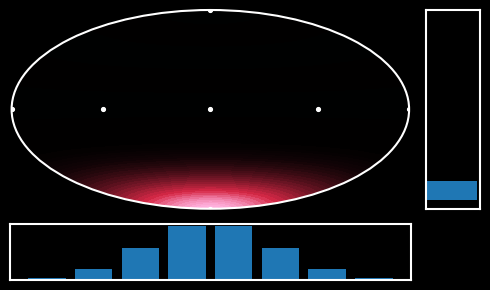

In [22]:
CatQB = CatQubit()
CatQB.set_black_blackground()
CatQB.initialize()
CatQB.plot_state()

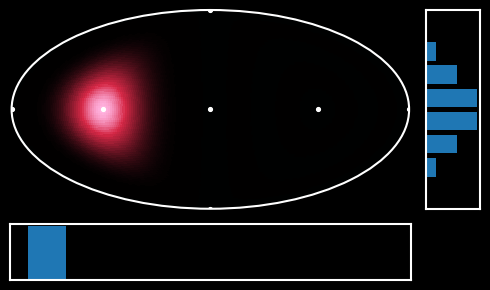

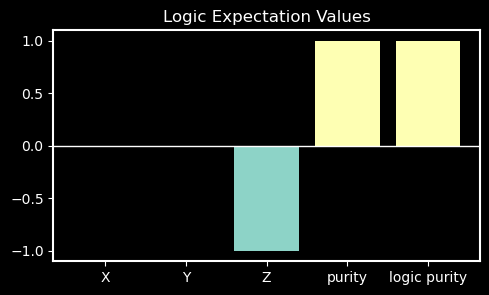

<Axes: title={'center': 'Logic Expectation Values'}>

In [23]:
CatQB.initialize()
CatQB.encode()
CatQB.plot_state()
CatQB.plot_logic_exp_values()

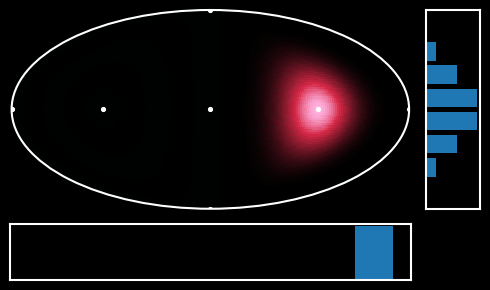

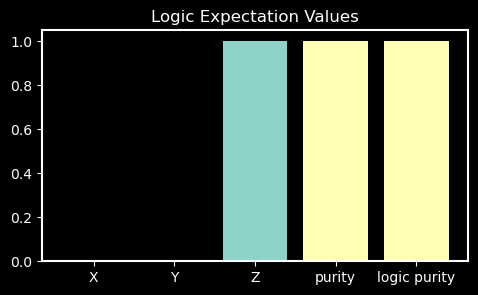

<Axes: title={'center': 'Logic Expectation Values'}>

In [24]:
CatQB.initialize()
CatQB.encode()
CatQB.LRx_gate(np.pi)
CatQB.plot_state()
CatQB.plot_logic_exp_values()

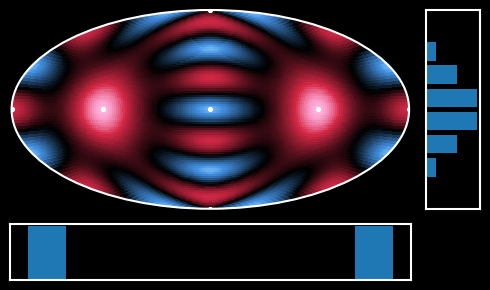

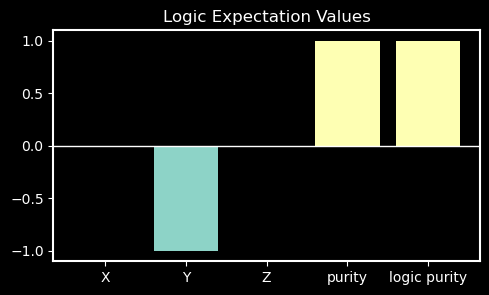

<Axes: title={'center': 'Logic Expectation Values'}>

In [25]:
CatQB.initialize()
CatQB.encode()
CatQB.LRx_gate(np.pi/2)
CatQB.plot_state()
CatQB.plot_logic_exp_values()

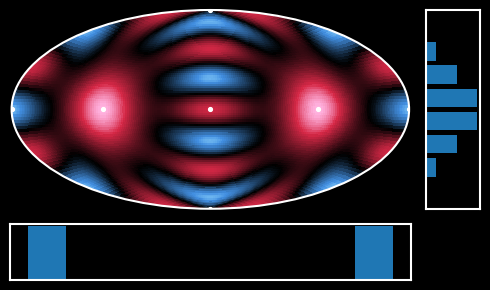

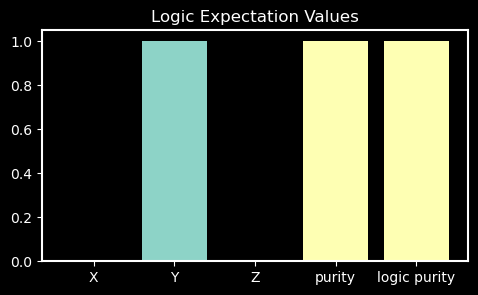

<Axes: title={'center': 'Logic Expectation Values'}>

In [27]:
CatQB.initialize()
CatQB.encode()
CatQB.LRx_gate(np.pi/2)
CatQB.LRz_gate(np.pi)
CatQB.plot_state()
CatQB.plot_logic_exp_values()

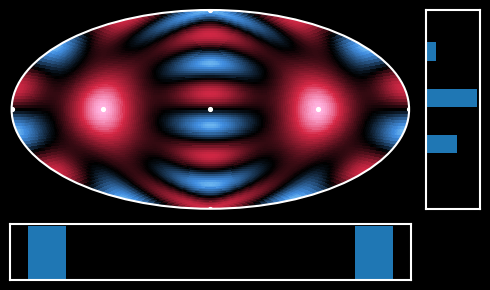

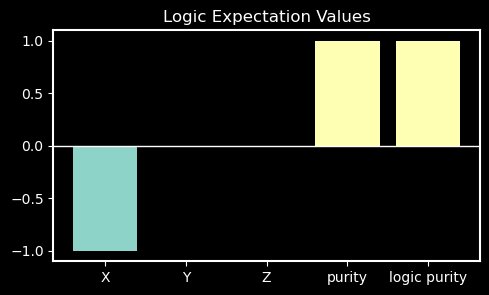

<Axes: title={'center': 'Logic Expectation Values'}>

In [28]:
CatQB.initialize()
CatQB.encode()
CatQB.LRx_gate(np.pi/2)
CatQB.LRz_gate(np.pi/2)
CatQB.plot_state()
CatQB.plot_logic_exp_values()

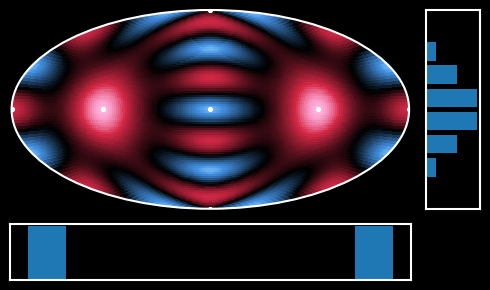

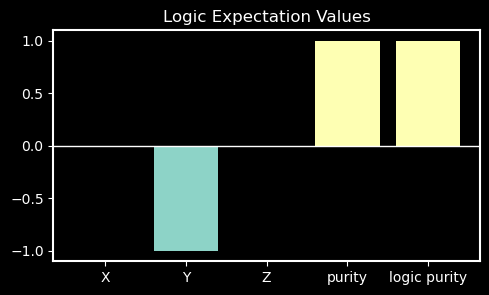

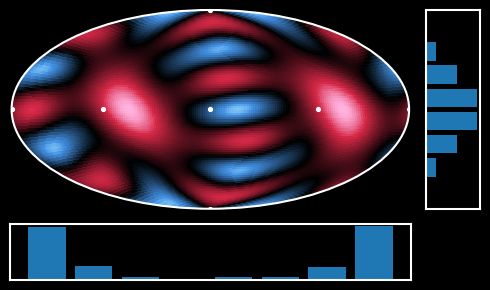

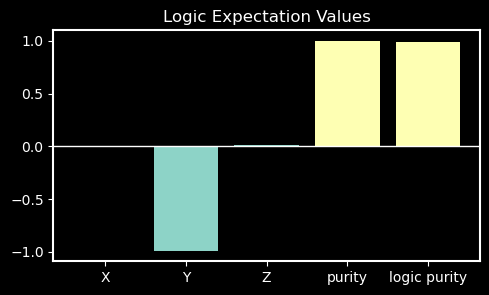

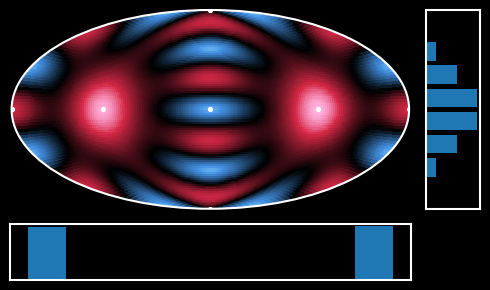

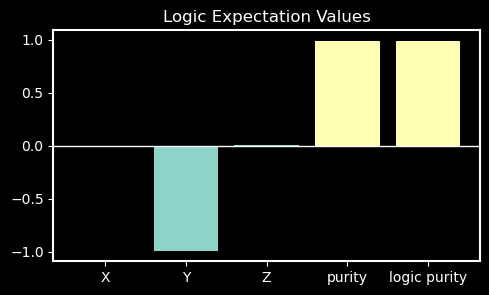

<Axes: title={'center': 'Logic Expectation Values'}>

In [30]:
CatQB = CatQubit()
CatQB.set_black_blackground()
CatQB.initialize()
CatQB.encode()
CatQB.LRx_gate(np.pi/2)
CatQB.plot_state()
CatQB.plot_logic_exp_values()
# CatQB.LRz_gate(np.pi/2)
# CatQB.LRx_gate(np.pi/2)
CatQB.phase_error(Iz=np.pi/8, Iz_sq=np.pi/16)
CatQB.plot_state()
CatQB.plot_logic_exp_values()

CatQB.correct_errors()
CatQB.plot_state()
CatQB.plot_logic_exp_values()

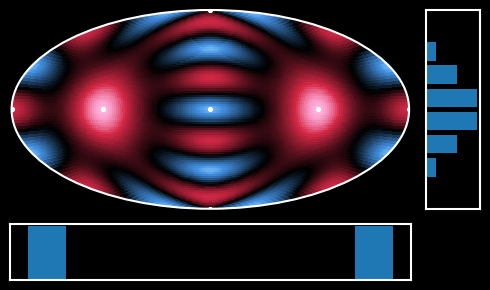

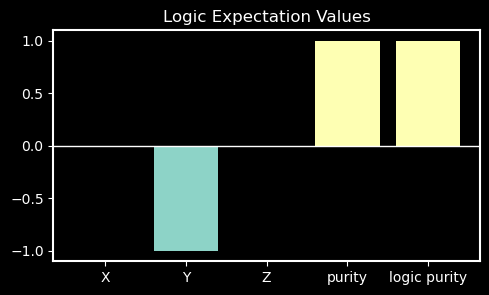

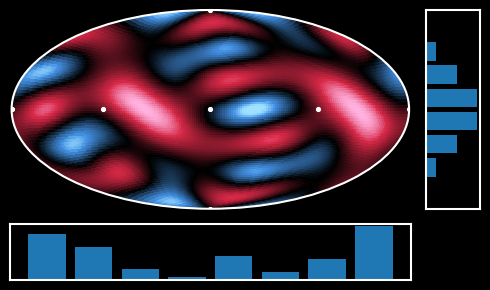

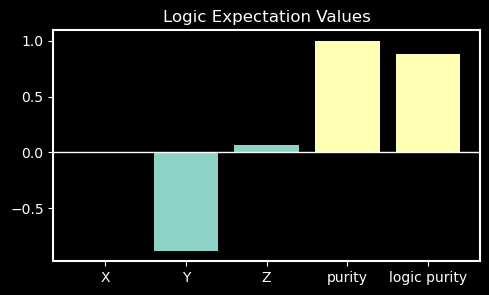

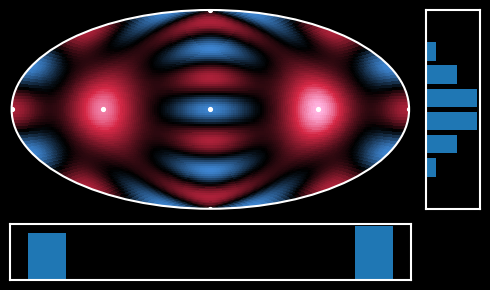

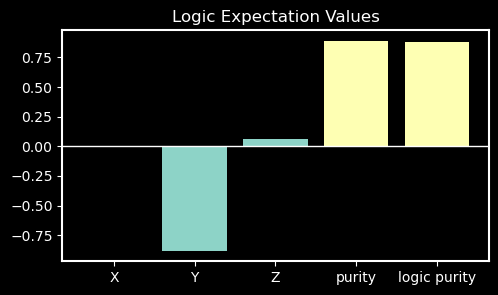

<Axes: title={'center': 'Logic Expectation Values'}>

In [34]:
CatQB = CatQubit()
CatQB.set_black_blackground()
CatQB.initialize()
CatQB.encode()
CatQB.LRx_gate(np.pi/2)
CatQB.plot_state()
CatQB.plot_logic_exp_values()
# CatQB.LRz_gate(np.pi/2)
# CatQB.LRx_gate(np.pi/2)
CatQB.phase_error(Iz=np.pi/5, Iz_sq=np.pi/8)
CatQB.plot_state()
CatQB.plot_logic_exp_values()

CatQB.correct_errors()
CatQB.plot_state()
CatQB.plot_logic_exp_values()